## Merging MIDV and FantasyID metadata

At this stage, the cleaned MIDV and FantasyID metadata tables are merged into a single master image metadata table.

This merge is performed before integrating FMIDV in order to:
- verify that the preprocessing outputs are compatible,
- create a unified structure for later image analysis,
- and prepare an initial version of the image dataset for exploratory analysis and baseline modeling.

A common metadata schema is used so that shared fields are aligned across datasets, while dataset-specific fields are preserved where available.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from image_dataset_merge import merge_image_metadata, save_metadata

midv_csv = project_root / "data" / "processed" / "midv_metadata.csv"
fantasy_csv = project_root / "data" / "processed" / "fantasyid_metadata.csv"
output_path = project_root / "data" / "processed" / "image_metadata_master.csv"

df_images = merge_image_metadata(midv_csv, fantasy_csv)

print(df_images.head())
print(df_images.shape)
print(df_images["final_label"].value_counts(dropna=False))
print(df_images["source_dataset"].value_counts(dropna=False))
print(df_images.groupby(["source_dataset", "final_label"]).size())

save_metadata(df_images, output_path)

     sample_id source_dataset  \
0  midv_000000           midv   
1  midv_000001           midv   
2  midv_000002           midv   
3  midv_000003           midv   
4  midv_000004           midv   

                                          image_path file_name file_stem  \
0  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    00.jpg         0   
1  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    01.jpg         1   
2  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    02.jpg         2   
3  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    03.jpg         3   
4  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    04.jpg         4   

  final_label  is_synthetic  width  height relative_path split_source  \
0   bona_fide         False   2268    4032          None         None   
1   bona_fide         False   2268    4032          None         None   
2   bona_fide         False   2268    4032          None         None   
3   bona_fide         False   2268    4032          

In [2]:
df_images.head(10)

,sample_id,source_dataset,image_path,file_name,file_stem,final_label,is_synthetic,width,height,relative_path,split_source,original_folder,image_class,capture_type,attack_type,source_type,doc_type,annotation_path
0,midv_000000,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,00.jpg,0,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
1,midv_000001,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,01.jpg,1,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
2,midv_000002,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,02.jpg,2,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
3,midv_000003,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,03.jpg,3,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
4,midv_000004,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,04.jpg,4,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
5,midv_000005,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,05.jpg,5,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
6,midv_000006,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,06.jpg,6,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
7,midv_000007,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,07.jpg,7,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
8,midv_000008,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,08.jpg,8,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...
9,midv_000009,midv,c:\Users\Admin\Desktop\thesis\multimodal-fraud...,09.jpg,9,bona_fide,False,2268,4032,None,None,None,None,None,None,photo,alb_id,c:\Users\Admin\Desktop\thesis\multimodal-fraud...


In [5]:
df_images.groupby(["source_dataset", "final_label"]).size()

source_dataset  final_label
fantasyid       bona_fide       933
                fraudulent     2351
midv            bona_fide      4000
dtype: int64

The MIDV and FantasyID metadata tables were successfully merged into a single master image metadata table.

The merged dataset contains 7,284 images in total:
- 4,933 labeled as `bona_fide`
- 2,351 labeled as `fraudulent`

In terms of dataset contribution:
- MIDV provides 4,000 bona fide images,
- FantasyID provides 933 bona fide images,
- FantasyID provides 2,351 fraudulent images.

This confirms that the merge was successful and that the current image dataset is suitable for preliminary exploratory analysis and an initial binary classification baseline.

## Exploratory analysis of the merged image dataset

After merging MIDV and FantasyID into a single master metadata table, exploratory analysis was performed to inspect class balance and source contribution. This step helps identify potential dataset imbalance and source-related bias before model training.

In [6]:
df_images.head(10)
df_images.columns
df_images["final_label"].value_counts()
df_images["source_dataset"].value_counts()
df_images.groupby(["source_dataset", "final_label"]).size()

source_dataset  final_label
fantasyid       bona_fide       933
                fraudulent     2351
midv            bona_fide      4000
dtype: int64

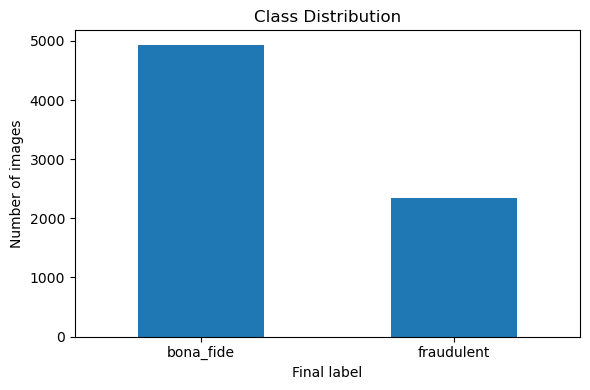

In [7]:
import matplotlib.pyplot as plt

class_counts = df_images["final_label"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Final label")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The merged image dataset is imbalanced, with a larger number of bona fide images than fraudulent images. However, both classes are sufficiently represented for an initial binary classification experiment.

<Figure size 700x400 with 0 Axes>

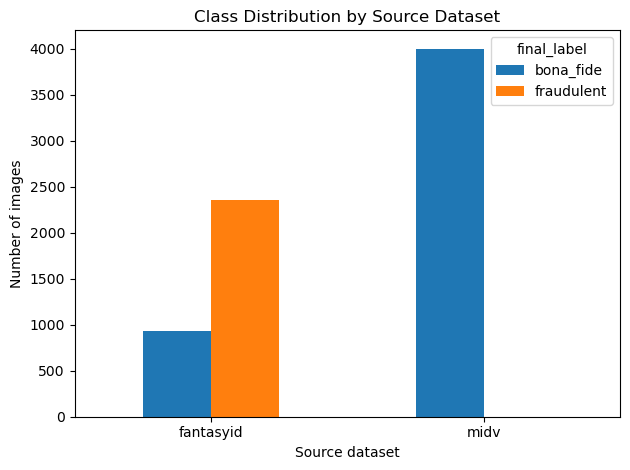

In [8]:
source_class_counts = df_images.groupby(["source_dataset", "final_label"]).size().unstack(fill_value=0)

plt.figure(figsize=(7, 4))
source_class_counts.plot(kind="bar")
plt.title("Class Distribution by Source Dataset")
plt.xlabel("Source dataset")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The class contribution differs by dataset source. MIDV contributes only bona fide samples, whereas FantasyID contributes both bona fide and fraudulent samples. This should be taken into account when interpreting model performance, since dataset-specific patterns may influence classification results.

In [9]:
source_class_counts

final_label,bona_fide,fraudulent
source_dataset,,
fantasyid,933,2351
midv,4000,0


In [10]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
merged_path = project_root / "data" / "processed" / "image_metadata_master.csv"

df_images = pd.read_csv(merged_path)

print(df_images.head())
print(df_images.shape)
print(df_images.columns)

     sample_id source_dataset  \
0  midv_000000           midv   
1  midv_000001           midv   
2  midv_000002           midv   
3  midv_000003           midv   
4  midv_000004           midv   

                                          image_path file_name file_stem  \
0  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    00.jpg         0   
1  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    01.jpg         1   
2  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    02.jpg         2   
3  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    03.jpg         3   
4  c:\Users\Admin\Desktop\thesis\multimodal-fraud...    04.jpg         4   

  final_label  is_synthetic  width  height relative_path split_source  \
0   bona_fide         False   2268    4032           NaN          NaN   
1   bona_fide         False   2268    4032           NaN          NaN   
2   bona_fide         False   2268    4032           NaN          NaN   
3   bona_fide         False   2268    4032          

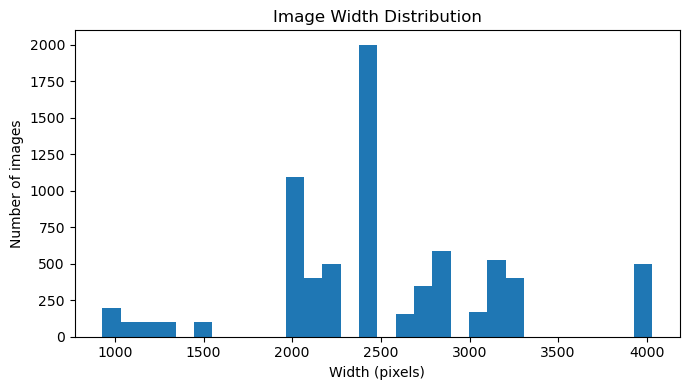

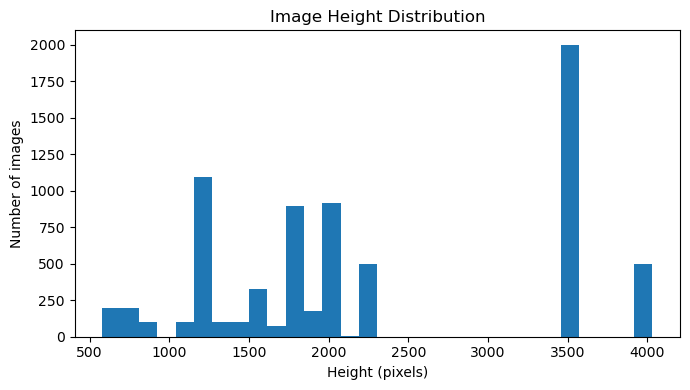

In [11]:
plt.figure(figsize=(7, 4))
df_images[df_images["width"].notna()]["width"].plot(kind="hist", bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
df_images[df_images["height"].notna()]["height"].plot(kind="hist", bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

Both width and height distributions are clearly multimodal, which means the merged dataset contains several common image-size groups rather than one standard resolution.

This suggests that:

- images come from different acquisition pipelines,
- different devices or capture settings were used,
- and the merged dataset is heterogeneous in resolution.

That is exactly what we would expect after combining MIDV and FantasyID.

 As a result, image resizing and normalization will be required before model training in order to provide the classifier with a consistent input format. It reflects that some visual properties may reflect dataset origin rather than only fraud-related content.

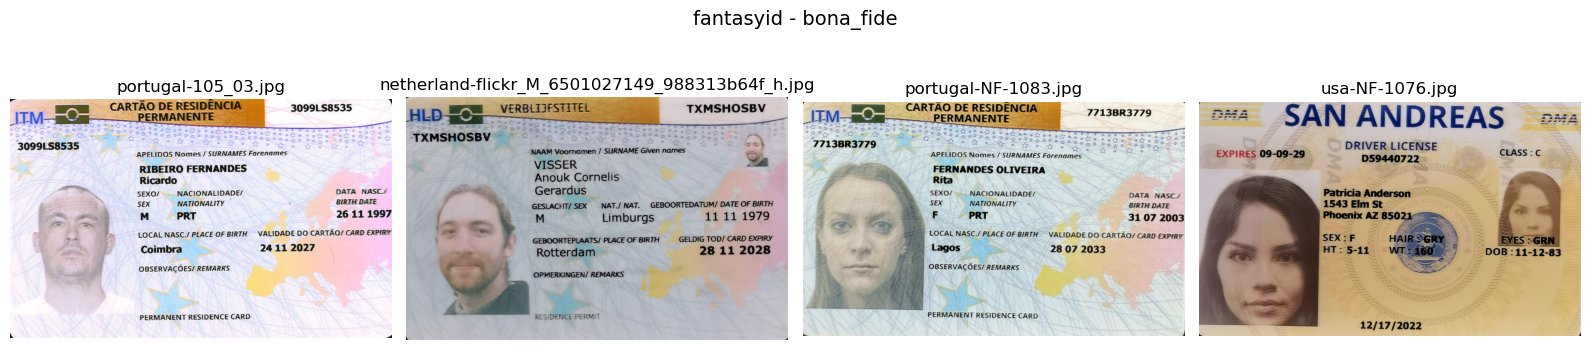

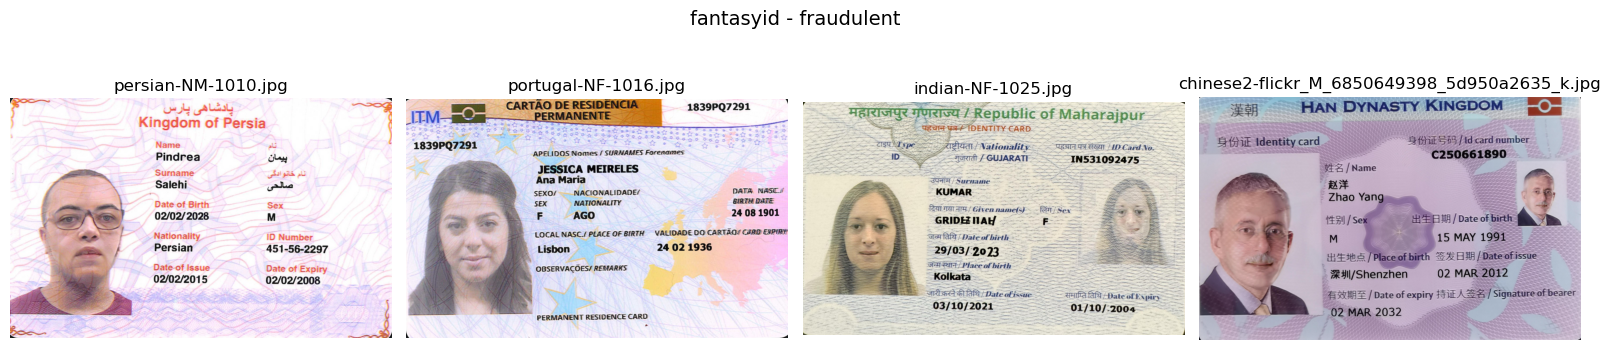

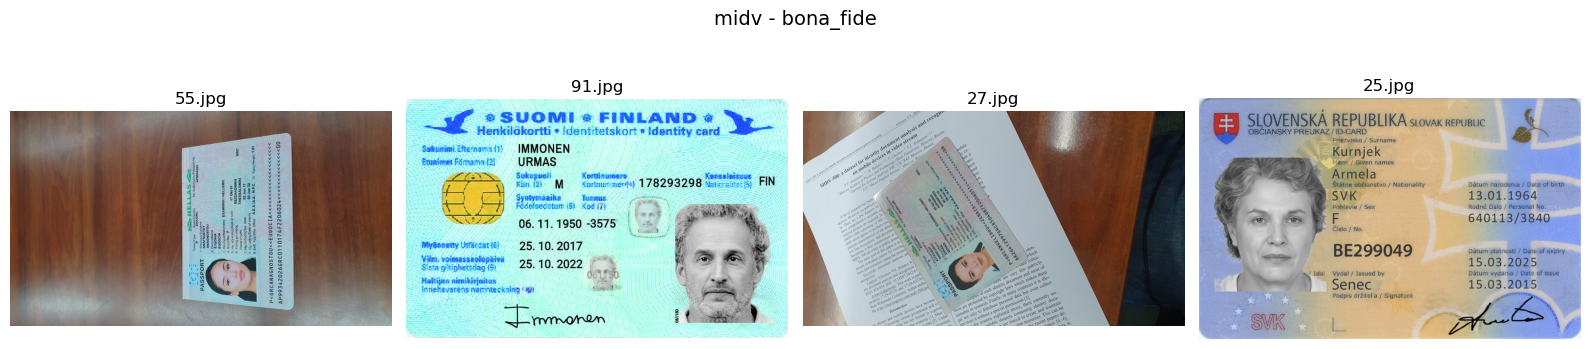

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

grouped = df_images.groupby(["source_dataset", "final_label"])

for (source, label), group in grouped:
    sample_n = min(4, len(group))
    sample_rows = group.sample(sample_n, random_state=42)

    fig, axes = plt.subplots(1, sample_n, figsize=(4 * sample_n, 4))
    if sample_n == 1:
        axes = [axes]

    fig.suptitle(f"{source} - {label}", fontsize=14)

    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        img = Image.open(row["image_path"])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(row["file_name"])

    plt.tight_layout()
    plt.show()

In [4]:
from pathlib import Path
import pandas as pd

processed_dir = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed")

midv_file = processed_dir / "midv_metadata_genuine.csv"
fantasy_file = processed_dir / "fantasyid_final_metadata.csv"
fmidv_file = processed_dir / "fmidv_subset_manifest.csv"

df_midv = pd.read_csv(midv_file)
df_fantasy = pd.read_csv(fantasy_file)
df_fmidv = pd.read_csv(fmidv_file)

print("MIDV shape:", df_midv.shape)
print("FantasyID shape:", df_fantasy.shape)
print("FMIDV shape:", df_fmidv.shape)

MIDV shape: (4000, 7)
FantasyID shape: (3284, 12)
FMIDV shape: (2880, 19)


In [5]:
print("MIDV columns:", list(df_midv.columns))
print("FantasyID columns:", list(df_fantasy.columns))
print("FMIDV columns:", list(df_fmidv.columns))

print("\nMIDV head:")
print(df_midv.head(3))

print("\nFantasyID head:")
print(df_fantasy.head(3))

print("\nFMIDV head:")
print(df_fmidv.head(3))


MIDV columns: ['source_type', 'doc_type', 'file_name', 'file_stem', 'image_path', 'annotation_path', 'image_label']
FantasyID columns: ['image_id', 'image_path', 'relative_path', 'split', 'class_name', 'image_label', 'is_attack_final', 'attack_type_final', 'attack_group', 'capture_type', 'width', 'height']
FMIDV columns: ['path', 'relative_path', 'top_folder', 'doc_type', 'filename', 'sample_id', 'capture_type', 'patch_size', 'zone_count', 'label', 'group_key', 'width', 'height', 'mode', 'read_error', 'file_size_mb', 'variant', 'source_dataset', 'image_class']

MIDV head:
  source_type doc_type file_name  file_stem  \
0       photo   alb_id    00.jpg          0   
1       photo   alb_id    01.jpg          1   
2       photo   alb_id    02.jpg          2   

                                          image_path  \
0  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
1  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   
2  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   

       

In [6]:
import pandas as pd
from pathlib import Path

processed_dir = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed")

# -----------------------------
# 1. MIDV -> bona_fide
# -----------------------------
midv_final = df_midv.copy()

midv_final["source_dataset"] = "midv"
midv_final["image_class"] = "bona_fide"

# build group key from doc_type + file stem
midv_final["file_stem_str"] = midv_final["file_stem"].astype(str).str.zfill(2)
midv_final["group_key"] = midv_final["doc_type"].astype(str) + "__" + midv_final["file_stem_str"]

midv_final = midv_final.rename(columns={
    "image_path": "image_path_final"
})

midv_final = midv_final[
    ["image_path_final", "source_dataset", "image_class", "group_key", "doc_type", "source_type", "file_name"]
].copy()

# -----------------------------
# 2. FantasyID -> bona_fide / forged
# -----------------------------
fantasy_final = df_fantasy.copy()

fantasy_final["source_dataset"] = "fantasyid"

# map labels
# image_label: 0 = bona fide, 1 = attack/forged
fantasy_final["image_class"] = fantasy_final["image_label"].map({
    0: "bona_fide",
    1: "forged",
    0.0: "bona_fide",
    1.0: "forged"
})

# fallback via class_name if needed
fantasy_final.loc[
    fantasy_final["image_class"].isna() & fantasy_final["class_name"].astype(str).str.lower().eq("attack"),
    "image_class"
] = "forged"

fantasy_final.loc[
    fantasy_final["image_class"].isna() & fantasy_final["class_name"].astype(str).str.lower().isin(["bonafide", "bona_fide", "real", "genuine"]),
    "image_class"
] = "bona_fide"

# use image_id as group key for now
fantasy_final["group_key"] = fantasy_final["image_id"].astype(str)

fantasy_final = fantasy_final.rename(columns={
    "image_path": "image_path_final"
})

fantasy_final = fantasy_final[
    ["image_path_final", "source_dataset", "image_class", "group_key", "split", "class_name", "attack_type_final", "attack_group", "capture_type"]
].copy()

fantasy_final["doc_type"] = pd.NA
fantasy_final["source_type"] = fantasy_final["capture_type"]
fantasy_final["file_name"] = fantasy_final["image_path_final"].apply(lambda x: Path(x).name)

fantasy_final = fantasy_final[
    ["image_path_final", "source_dataset", "image_class", "group_key", "doc_type", "source_type", "file_name",
     "split", "class_name", "attack_type_final", "attack_group"]
].copy()

# keep only rows with valid mapped class
fantasy_final = fantasy_final[fantasy_final["image_class"].isin(["bona_fide", "forged"])].copy()

# -----------------------------
# 3. FMIDV -> forged
# -----------------------------
fmidv_final = df_fmidv.copy()

fmidv_final = fmidv_final.rename(columns={
    "path": "image_path_final"
})

fmidv_final["source_dataset"] = "fmidv"
fmidv_final["image_class"] = "forged"
fmidv_final["source_type"] = fmidv_final["capture_type"]
fmidv_final["file_name"] = fmidv_final["filename"]

fmidv_final = fmidv_final[
    ["image_path_final", "source_dataset", "image_class", "group_key", "doc_type", "source_type", "file_name",
     "patch_size", "zone_count", "variant", "top_folder"]
].copy()

# -----------------------------
# 4. ALIGN COLUMNS
# -----------------------------
common_cols = [
    "image_path_final",
    "source_dataset",
    "image_class",
    "group_key",
    "doc_type",
    "source_type",
    "file_name"
]

midv_final = midv_final.reindex(columns=common_cols)
fantasy_final = fantasy_final.reindex(columns=common_cols)
fmidv_final = fmidv_final.reindex(columns=common_cols)

# -----------------------------
# 5. MERGE
# -----------------------------
image_dataset_final = pd.concat(
    [midv_final, fantasy_final, fmidv_final],
    ignore_index=True
)

image_dataset_final = image_dataset_final.sort_values(
    ["image_class", "source_dataset", "group_key"]
).reset_index(drop=True)

# -----------------------------
# 6. SAVE
# -----------------------------
final_path = processed_dir / "image_dataset_final.csv"
image_dataset_final.to_csv(final_path, index=False)

# -----------------------------
# 7. CHECKS
# -----------------------------
print("Final dataset size:", len(image_dataset_final))
print("\nClass counts:")
print(image_dataset_final["image_class"].value_counts())

print("\nSource x class:")
print(pd.crosstab(image_dataset_final["source_dataset"], image_dataset_final["image_class"]))

print("\nUnique groups by source:")
print(image_dataset_final.groupby("source_dataset")["group_key"].nunique())

print("\nSaved to:", final_path)

image_dataset_final.head(10)

Final dataset size: 10164

Class counts:
image_class
forged       5231
bona_fide    4933
Name: count, dtype: int64

Source x class:
image_class     bona_fide  forged
source_dataset                   
fantasyid             933    2351
fmidv                   0    2880
midv                 4000       0

Unique groups by source:
source_dataset
fantasyid     362
fmidv         720
midv         1000
Name: group_key, dtype: int64

Saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\image_dataset_final.csv


,image_path_final,source_dataset,image_class,group_key,doc_type,source_type,file_name
0,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-003_03,<NA>,huawei,arabic-003_03.jpg
1,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-003_03,<NA>,iphone15pro,arabic-003_03.jpg
2,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-003_03,<NA>,scan,arabic-003_03.jpg
3,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-005_03,<NA>,huawei,arabic-005_03.jpg
4,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-005_03,<NA>,iphone15pro,arabic-005_03.jpg
5,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-005_03,<NA>,scan,arabic-005_03.jpg
6,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-024_03,<NA>,huawei,arabic-024_03.jpg
7,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-024_03,<NA>,iphone15pro,arabic-024_03.jpg
8,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-024_03,<NA>,scan,arabic-024_03.jpg
9,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,fantasyid,bona_fide,arabic-112_03,<NA>,huawei,arabic-112_03.jpg


In [7]:
print(df_fantasy["split"].value_counts(dropna=False))
print(pd.crosstab(df_fantasy["split"], fantasy_final["image_class"]))

split
train    1899
test     1385
Name: count, dtype: int64
image_class  bona_fide  forged
split                         
test               300    1085
train              633    1266


In [8]:
print("Duplicate image paths in final dataset:", image_dataset_final["image_path_final"].duplicated().sum())

Duplicate image paths in final dataset: 0


In [10]:
import pandas as pd
from pathlib import Path

processed_dir = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed")

image_train = pd.read_csv(processed_dir / "image_train.csv")
image_val = pd.read_csv(processed_dir / "image_val.csv")
image_test = pd.read_csv(processed_dir / "image_test.csv")

print("IMAGE TRAIN:", image_train.shape)
print(image_train["image_class"].value_counts())

print("\nIMAGE VAL:", image_val.shape)
print(image_val["image_class"].value_counts())

print("\nIMAGE TEST:", image_test.shape)
print(image_test["image_class"].value_counts())

IMAGE TRAIN: (6653, 10)
image_class
bona_fide    3411
forged       3242
Name: count, dtype: int64

IMAGE VAL: (1743, 10)
image_class
forged       906
bona_fide    837
Name: count, dtype: int64

IMAGE TEST: (2425, 10)
image_class
forged       1521
bona_fide     904
Name: count, dtype: int64
